In [12]:

import pandas as pd
df = pd.read_excel("student_performance_dataset.xlsx")
df.head()

,Student_ID,Name,Age,Gender,City,Department,Education_Level,Attendance_%,Study_Hours_Daily,Assignments,Quizzes,Midterm,Internet_Access,Final_Score
0,1,Uzma,24,Female,Lahore,CS,Intermediate,60.0,7.0,6.0,13,89.0,No,53
1,2,ZAHID,19,female,Karachi,SE,Intermediate,82.0,4.0,NaN,5,84.0,Yes,55
2,3,Sara,19,Female,Lahore,BBA,Intermediate,NaN,5.0,10.0,9,50.0,Yes,42
3,4,Zahid,22,Male,Rawalpindi,EE,Intermediate,98.0,7.0,8.0,8,68.0,Yes,49
4,5,Zahid,21,Male,Karachi,SE,Intermediate,98.0,3.0,5.0,17,75.0,Yes,49


In [3]:
#Data Load
# data info
print("Shape:", df.shape)
print("\nColumn Names and Data Types:\n", df.info())

# First and last 5 rows
print("\nFirst 5 rows:\n", df.head())
print("\nLast 5 rows:\n", df.tail())

# Statistical summary for numerical columns
print("\nDescribe:\n", df.describe())

# Missing values
print("\nMissing values per column:\n", df.isnull().sum())

Shape: (205, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student_ID         205 non-null    int64  
 1   Name               205 non-null    object 
 2   Age                205 non-null    object 
 3   Gender             205 non-null    object 
 4   City               205 non-null    object 
 5   Department         205 non-null    object 
 6   Education_Level    205 non-null    object 
 7   Attendance_%       189 non-null    float64
 8   Study_Hours_Daily  200 non-null    float64
 9   Assignments        195 non-null    float64
 10  Quizzes            205 non-null    int64  
 11  Midterm            195 non-null    float64
 12  Internet_Access    205 non-null    object 
 13  Final_Score        205 non-null    int64  
dtypes: float64(4), int64(3), object(7)
memory usage: 22.6+ KB

Column Names and Data Types:
 None

First 5 ro

In [8]:
#Data Cleaning
# 1. Fix Gender casing
df['Gender'] = df['Gender'].str.title()

# 2. Fix Name casing
df['Name'] = df['Name'].str.title()

# 3. Fix Department inconsistencies
df['Department'] = df['Department'].str.upper().str.strip()

# 4. Fix Age: convert text to NaN then numeric
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Fill missing Age with median (SAFE way)
df['Age'] = df['Age'].fillna(df['Age'].median())

# 5. Fix impossible values
df.loc[(df['Attendance_%'] < 0) | (df['Attendance_%'] > 100), 'Attendance_%'] = np.nan
df.loc[(df['Final_Score'] < 0) | (df['Final_Score'] > 100), 'Final_Score'] = np.nan

# 6. Fill missing numerical values (SAFE loop)
num_cols = ['Attendance_%', 'Study_Hours_Daily', 'Assignments', 'Midterm', 'Final_Score']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# 7. Remove duplicate rows
df = df.drop_duplicates()

# Final check
print("Missing values after cleaning:\n", df.isnull().sum())

Missing values after cleaning:
 Student_ID           0
Name                 0
Age                  0
Gender               0
City                 0
Department           0
Education_Level      0
Attendance_%         0
Study_Hours_Daily    0
Assignments          0
Quizzes              0
Midterm              0
Internet_Access      0
Final_Score          0
dtype: int64


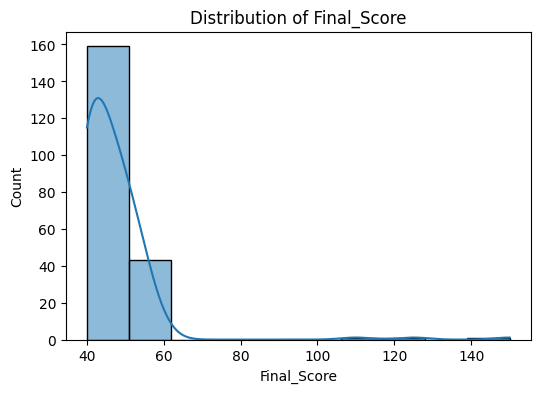

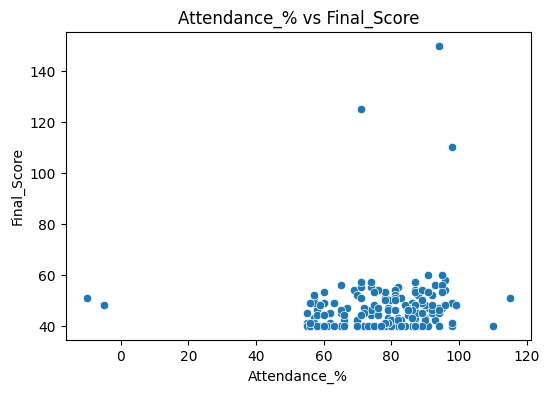

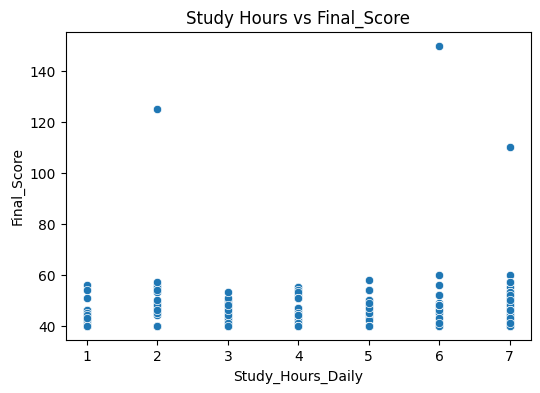

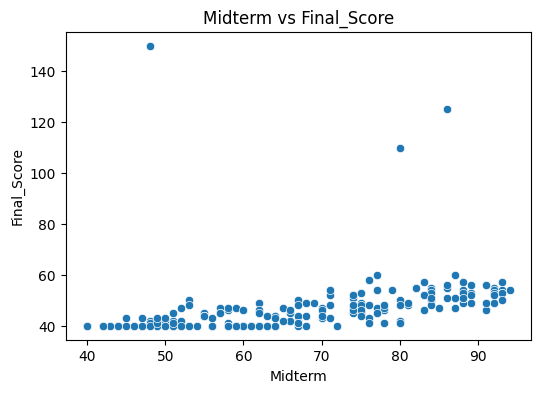

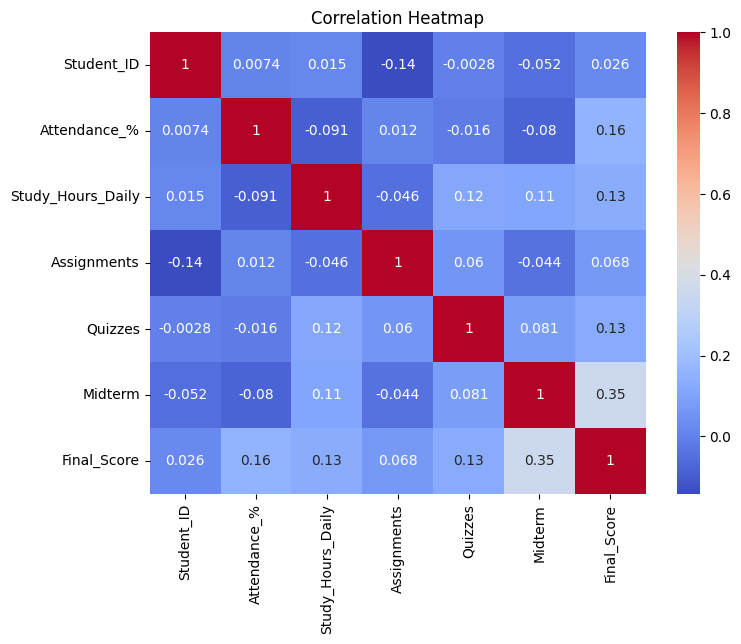

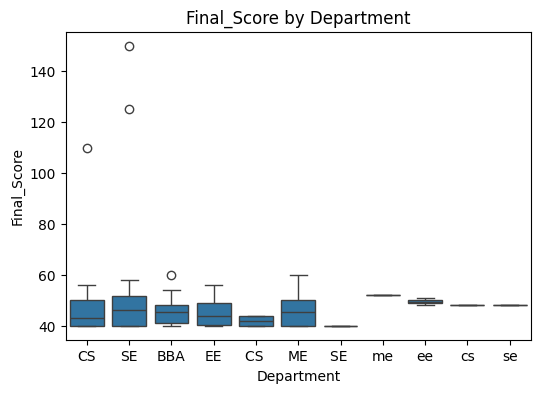

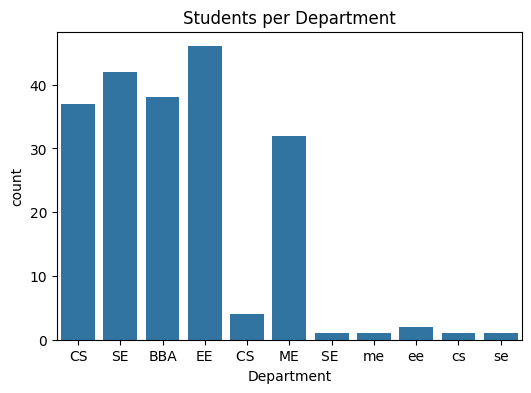

In [13]:
#Exploratory Data Analysis
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Distribution of Final_Score
plt.figure(figsize=(6,4))
sns.histplot(df['Final_Score'], kde=True, bins=10)
plt.title("Distribution of Final_Score")
plt.show()

# 2. Attendance_% vs Final_Score
plt.figure(figsize=(6,4))
sns.scatterplot(x='Attendance_%', y='Final_Score', data=df)
plt.title("Attendance_% vs Final_Score")
plt.show()

# 3. Study_Hours_Daily vs Final_Score
plt.figure(figsize=(6,4))
sns.scatterplot(x='Study_Hours_Daily', y='Final_Score', data=df)
plt.title("Study Hours vs Final_Score")
plt.show()

# 4. Midterm vs Final_Score
plt.figure(figsize=(6,4))
sns.scatterplot(x='Midterm', y='Final_Score', data=df)
plt.title("Midterm vs Final_Score")
plt.show()

# 5. Correlation heatmap
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# 6. Final_Score by Department
plt.figure(figsize=(6,4))
sns.boxplot(x='Department', y='Final_Score', data=df)
plt.title("Final_Score by Department")
plt.show()

# 7. Count of students per Department
plt.figure(figsize=(6,4))
sns.countplot(x='Department', data=df)
plt.title("Students per Department")
plt.show()

In [10]:
#Feature Engineering & Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Feature Engineering
df['Total_Academic'] = df['Assignments']*5 + df['Quizzes']*2 + df['Midterm']

# Attendance category
df['Attendance_Category'] = pd.cut(df['Attendance_%'], bins=[0,60,80,100], labels=['Low','Medium','High'])

# Drop non-predictive columns
X = df.drop(['Student_ID','Name','Final_Score'], axis=1)
y = df['Final_Score']

# Categorical columns
cat_ohe = ['Gender', 'Internet_Access', 'City', 'Department']
cat_ord = ['Education_Level', 'Attendance_Category']

# Ordinal mapping
education_order = ['Intermediate', 'Bachelors', 'Masters']
attendance_order = ['Low','Medium','High']

# Train-test split first
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Column transformer
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), ['Age','Attendance_%','Study_Hours_Daily','Assignments','Quizzes','Midterm','Total_Academic']),
    ('ohe', OneHotEncoder(), cat_ohe),
    ('ord', OrdinalEncoder(categories=[education_order, attendance_order]), cat_ord)
])

# Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Train
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Attendance_%',
                                                   'Study_Hours_Daily',
                                                   'Assignments', 'Quizzes',
                                                   'Midterm',
                                                   'Total_Academic']),
                                                 ('ohe', OneHotEncoder(),
                                                  ['Gender', 'Internet_Access',
                                                   'City', 'Department']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['Intermediate',
                                                                              'Bachelors',
                                                                              'Masters'],
                                                                             ['Low',
                                                                              'Medium',
                                                                              'High']]),
                                                  ['Education_Level',
                                                   'Attendance_Category'])])),
                ('model', LinearRegression())])

Coefficients: [ 0.07538449  1.88323922  0.35803183  0.52184701 -0.76469242  2.6356668
  1.85609623  0.38735455 -0.38735455  0.09164157 -0.09164157 -0.31991681
  0.24412371  0.05267083  0.91246985 -0.88934758 -0.15305261 -1.05869613
  0.05976817  0.79920854  0.35277203 -0.15604629 -0.84173699]
Intercept: 46.75735674267974

MAE: 2.45
RMSE: 3.27
R²: 0.59


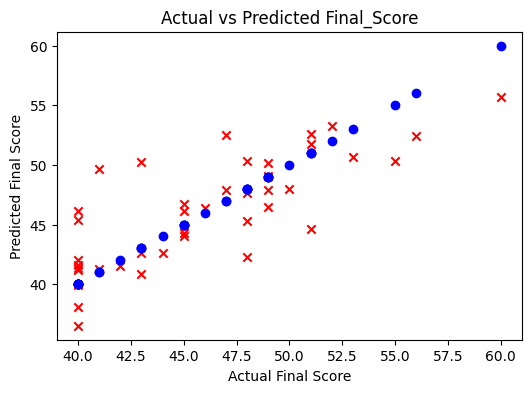

In [11]:
# Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict
y_pred = pipeline.predict(X_test)

# Actual vs Predicted for first 10
pd.DataFrame({'Actual': y_test[:10].values, 'Predicted': y_pred[:10]}).reset_index(drop=True)

# Model coefficients
trained_model = pipeline.named_steps['model']
print("Coefficients:", trained_model.coef_)
print("Intercept:", trained_model.intercept_)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nMAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

# Actual vs Predicted Scatter
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, color='red', marker='x')
plt.scatter(y_test, y_test, color='blue')  # perfect prediction line
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Final_Score")
plt.show()

**Conclusion:**
The Linear Regression model predicts student Final_Score using academic and demographic features. The model achieved R² = 0.59, explaining ~59% of score variability. The strongest predictors were Midterm score, Attendance_%, and Assignments, while other features like Age and City had minimal impact. MAE = 2.45 and RMSE = 3.27 indicate predictions are on average ±2–3 points from actual scores.
This model is interpretable and highlights which factors most influence performance. To improve, future work could explore non-linear models (Random Forest, Gradient Boosting), interaction features, or additional student behavior data. Overall, understanding why R² is 0.59 is more valuable than arbitrarily increasing it, as the model reflects realistic variation in student performance